<a href="https://colab.research.google.com/github/Sigurd-RW/lis4693/blob/main/Lab7/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
import requests
import io
import tarfile

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
response = requests.get(url)
response.raise_for_status()

file_like = io.BytesIO(response.content)
tar = tarfile.open(fileobj=file_like, mode="r:gz")
tar.extractall()

print("Archive extracted to local filesystem.")

/tmp/ipykernel_9120/2483758650.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Archive extracted to local filesystem.


In [3]:
import os
import pandas as pd

texts = []
labels = []
object_ids = [] # New list for ObjectIds
review_counter = 0 # Counter for unique ObjectIds

for label in ["pos", "neg"]:
    path = f"aclImdb/train/{label}"

    for file in os.listdir(path):
        with open(os.path.join(path, file), encoding="utf-8") as f:
            texts.append(f.read())
            labels.append(label)
            object_ids.append(f"review_{review_counter}") # Assign a unique ObjectId
            review_counter += 1

df = pd.DataFrame({
    "ObjectId": object_ids, # Add ObjectId column
    "Description": texts, # Rename 'text' to 'Description'
    "sentiment": labels
})

print(df.head())

   ObjectId                                        Description sentiment
0  review_0  This is without doubt the best documentary eve...       pos
1  review_1  Released two years before I was born, this Osc...       pos
2  review_2  I found this film to funny from the start. Joh...       pos
3  review_3  The film is hugely enjoyable with a great cast...       pos
4  review_4  Having to have someone hold your hand whenever...       pos


In [4]:
df_subset = df[['ObjectId', 'Description']].copy()

In [5]:
df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", " ", regex=True)

In [6]:
df_subset['Description'] = df_subset['Description'].str.casefold()
print(df_subset.head(10))

   ObjectId                                        Description
0  review_0  this is without doubt the best documentary eve...
1  review_1  released two years before i was born  this osc...
2  review_2  i found this film to funny from the start  joh...
3  review_3  the film is hugely enjoyable with a great cast...
4  review_4  having to have someone hold your hand whenever...
5  review_5  i wasn t expecting to be so impacted by this f...
6  review_6  i really enjoyed this movie and it was a littl...
7  review_7  this movie is all about subtlety and the diffi...
8  review_8  an excellent example of the spectacular busby ...
9  review_9  gung ho is one of those movies that i never ge...


In [7]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [8]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'ObjectId': row['ObjectId'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    ObjectId sentiment_type  sentiment_score
3   review_0       compound          -0.9677
7   review_1       compound           0.9881
11  review_2       compound           0.7261
15  review_3       compound           0.9749
19  review_4       compound           0.9988
23  review_5       compound           0.9246
27  review_6       compound          -0.0561
31  review_7       compound          -0.5574
35  review_8       compound           0.9874
39  review_9       compound           0.9484


In [9]:
df_output = pd.merge(df, t_df_cleaned, on='ObjectId', how='inner')
print(df_output.head(10))

def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_output['sentiment_category'] = df_output['sentiment_score'].apply(categorize_sentiment)

   ObjectId                                        Description sentiment  \
0  review_0  This is without doubt the best documentary eve...       pos   
1  review_1  Released two years before I was born, this Osc...       pos   
2  review_2  I found this film to funny from the start. Joh...       pos   
3  review_3  The film is hugely enjoyable with a great cast...       pos   
4  review_4  Having to have someone hold your hand whenever...       pos   
5  review_5  I wasn't expecting to be so impacted by this f...       pos   
6  review_6  I really enjoyed this movie and it was a littl...       pos   
7  review_7  This movie is all about subtlety and the diffi...       pos   
8  review_8  An excellent example of the spectacular Busby ...       pos   
9  review_9  Gung Ho is one of those movies that I never ge...       pos   

  sentiment_type  sentiment_score  
0       compound          -0.9677  
1       compound           0.9881  
2       compound           0.7261  
3       compound   

In [10]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,25000.000000
mean,0.311614
std,0.803856
min,-0.999700
25%,-0.666000
50%,0.838150
75%,0.974300
max,0.999900


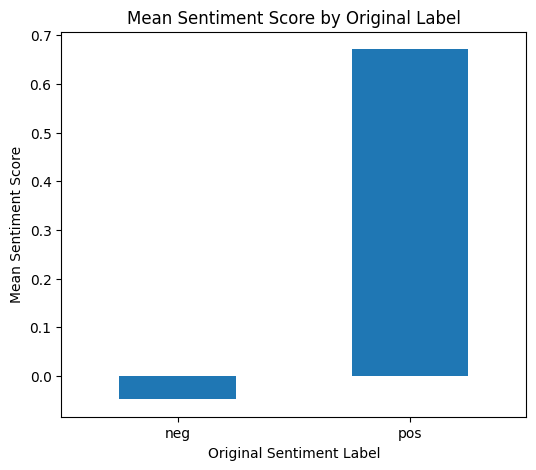

In [11]:
# Generate mean of sentiment_score by original sentiment label
dfg = df_output.groupby(['sentiment'])['sentiment_score'].mean()

# Create a bar plot
dfg.plot(kind='bar', title='Mean Sentiment Score by Original Label',
         ylabel='Mean Sentiment Score', xlabel='Original Sentiment Label', figsize=(6, 5))
plt.xticks(rotation=0)
plt.show()

<Axes: title={'center': 'sentiment_score'}, xlabel='sentiment_category', ylabel='Mean Sentiment Score'>

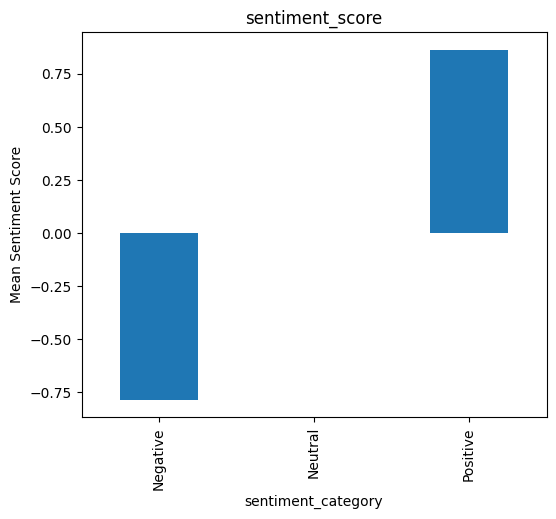

In [12]:
dfg = df_output.groupby(['sentiment_category'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='sentiment_category', figsize=(6, 5))

<Axes: title={'center': 'sentiment_score'}, xlabel='sentiment_category', ylabel='Mean Sentiment Score'>

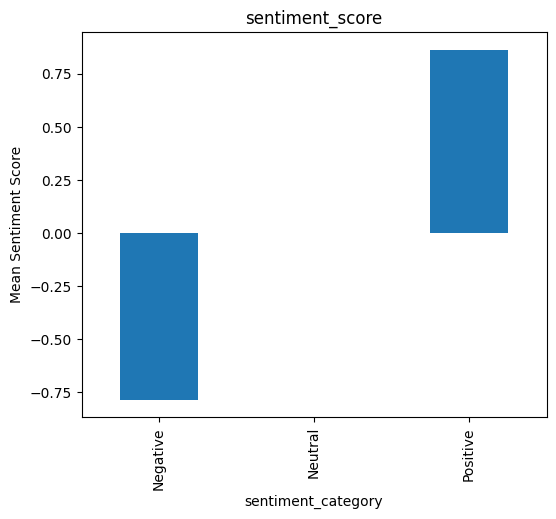

In [13]:
dfg = df_output.groupby(['sentiment_category'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='sentiment_category', figsize=(6, 5))

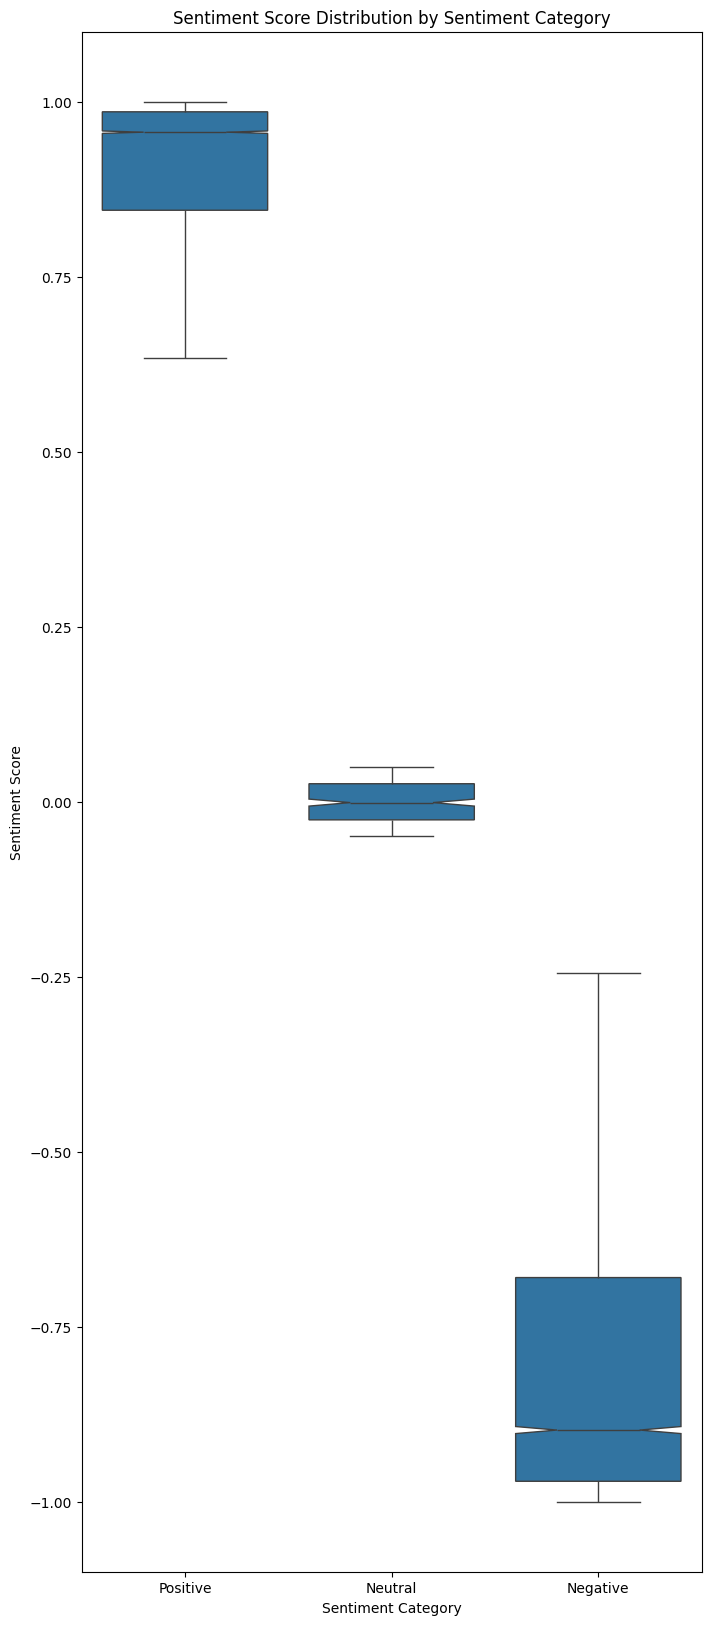

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create seaborn boxplots by sentiment category
plt.figure(figsize=(8, 20)) #8,6
sns.boxplot(x='sentiment_category', y='sentiment_score', notch=True,
            data=df_output, showfliers=False, order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Score Distribution by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=0)
plt.show()

In [15]:

!pip install "vl-convert-python>=1.6.0"

import altair as alt

# Prepare data for mean sentiment score by Sentiment
dfg_year = df_output.groupby('sentiment')['sentiment_score'].mean().reset_index()
dfg_year['sentiment'] = dfg_year['sentiment'].astype(str).str.replace(r'\\.0$', '', regex=True)

# Create the Altair bar chart for Sentiment Score by Sentiment
chart_year = alt.Chart(dfg_year).mark_bar().encode(
    x=alt.X('sentiment:N', title='Sentiment'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('sentiment:N', legend=alt.Legend(title="Sentiment")),
    tooltip=['sentiment', 'sentiment_score']
).properties(
    title='Mean Sentiment Score per Sentiment'
).interactive()

chart_year

alt.Chart(...)

In [16]:

import altair as alt

# Prepare data for mean sentiment score by sentiment_category
dfg_sentiment_category = df_output.groupby('sentiment_category')['sentiment_score'].mean().reset_index()

# Create the Altair bar chart for Sentiment Score by sentiment_category
chart_sentiment_category = alt.Chart(dfg_sentiment_category).mark_bar().encode(
    x=alt.X('sentiment_category:N', title='sentiment_category', sort='-y'), # Sort by sentiment score
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('sentiment_category:N', legend=alt.Legend(title="sentiment_category")),
    tooltip=['sentiment_category', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by sentiment_category'
).interactive()

chart_sentiment_category


alt.Chart(...)

In [17]:
import altair as alt
!pip install "vegafusion[embed]>=1.5.0"
alt.data_transformers.enable("vegafusion")

# Create the Altair box plot for Sentiment Score by sentiment_category
chart_boxplot = alt.Chart(df_output).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('sentiment_category:N', title='sentiment_category', axis=alt.Axis(labels=False)), # Hide x-axis labels as they can overlap
    y=alt.Y('sentiment_score:Q', title='Sentiment Score'),
    color=alt.Color('sentiment_category:N', legend=alt.Legend(title="sentiment_category")),
    tooltip=['sentiment_category', 'sentiment_score']
).properties(
    title='Sentiment Score Distribution by sentiment_category'
).interactive()

chart_boxplot

alt.Chart(...)

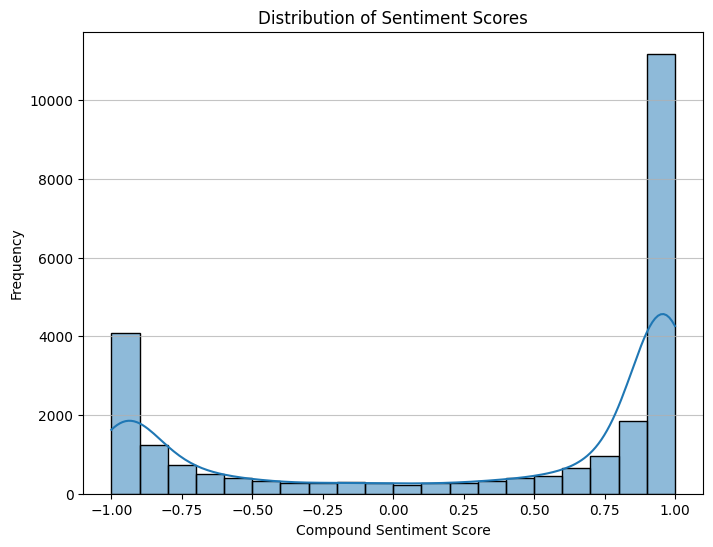

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of sentiment scores
fig1 = plt.figure(figsize=(8, 6))
sns.histplot(df_output['sentiment_score'], bins=20, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_9120/2091176863.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df_output, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


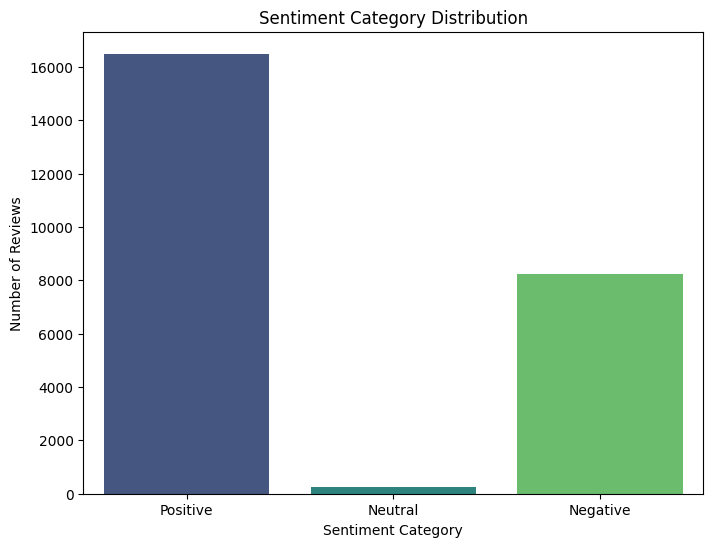

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot of sentiment categories
fig2 = plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_category', data=df_output, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Category Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

I merged by the Object ID because that's usually the go to for merging stuff since they're usually consistant across cleaned and uncleaned dataframes. The text field is of course, description since that's where the reviews are written.

Count = 25,000 reviews.

Mean score is 0.3116 = leaning positive sentiment.
Standard deviation is 0.8038, indicating wide range in sentiments.

Min = -0.997, lowest achieved score.

25% Q1 = -0.666, 25% of reviews are -0.666 or lower.

50% = 0.83815, half of scores are overall positive.

75% = 0.9743 - 75% of reviews are postive.

Max = 0.9999 - Maximum score given

I'd say it didn't go horribly besides the fact that I didn't have variables like Province and Year, but that's down to the dataset I was given. But the actual code itself wasn't that bad and I can see the value being presented with comparing more detailed mathamatical values of the sentiment in case I was in charge of analyzing the market value of a product.